In [1]:
import matplotlib.pyplot as plt
import open3d as o3d
import numpy as np
import os

import pyFM.spectral as spectral
from pyFM.mesh import TriMesh

from tqdm.auto import tqdm
import meshplot as mp

def double_plot_o3d(myMesh1,myMesh2,cmap1=None,cmap2=None):
    vertlist_1 = np.asarray(myMesh1.vertices)
    facelist_1 = np.asarray(myMesh1.triangles)

    vertlist_2 = np.asarray(myMesh2.vertices)
    facelist_2 = np.asarray(myMesh2.triangles)
    
    d = mp.subplot(vertlist_1, facelist_1, c=cmap1, s=[2, 2, 0])
    mp.subplot(vertlist_2, facelist_2, c=cmap2, s=[2, 2, 1], data=d)

def plot_mesh(myMesh,cmap=None):
    mp.plot(myMesh.vertlist, myMesh.facelist,c=cmap)
    
def double_plot(myMesh1,myMesh2,cmap1=None,cmap2=None):
    d = mp.subplot(myMesh1.vertlist, myMesh1.facelist, c=cmap1, s=[2, 2, 0])
    mp.subplot(myMesh2.vertlist, myMesh2.facelist, c=cmap2, s=[2, 2, 1], data=d)

def visu(vertices):
    min_coord,max_coord = np.min(vertices,axis=0,keepdims=True),np.max(vertices,axis=0,keepdims=True)
    cmap = (vertices-min_coord)/(max_coord-min_coord)
    return cmap

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Data Pre-Processing ____________________________________
(need to change this back to just doing it with o3d rather than TriMesh)
1. Load Meshes
2. Generate Intial Point to Point Maps 
3. Convert to Functional Maps

In [2]:
def clean_mesh(mesh):

    # Remove duplicate vertices
    mesh.remove_duplicated_vertices()
    # Remove degenerate triangles
    mesh.remove_degenerate_triangles()
    # Remove unreferenced vertices
    mesh.remove_unreferenced_vertices()

    # triangle_clusters, cluster_n_triangles, cluster_areas = mesh.cluster_connected_triangles()

    # # Find the index of the largest cluster (by area or by number of triangles)
    # largest_cluster_index = np.argmax(cluster_areas)

    # # Create a mask for triangles belonging to the largest cluster
    # mask = (np.asarray(triangle_clusters) == largest_cluster_index)

    # # Extract the corresponding triangles and vertices
    # new_triangles = np.asarray(mesh.triangles)[mask]
    # new_vertices = np.asarray(mesh.vertices)

    # # Build a new mesh
    # cleaned_mesh = o3d.geometry.TriangleMesh(
    #     o3d.utility.Vector3dVector(new_vertices),
    #     o3d.utility.Vector3iVector(new_triangles)
    # )

    # # Optionally, remove unreferenced vertices
    # cleaned_mesh = cleaned_mesh.remove_unreferenced_vertices()
    return mesh

# path = os.path.abspath('../simulation/meshes_dancer')
path = os.path.abspath('render_frame_000')

start_frame = 1
end_frame = 20
frames = [str(i).zfill(4) for i in range(start_frame, end_frame + 1)]

# load meshes
# mesh_list_o3d = [o3d.io.read_triangle_mesh(f'{path}/frame_{frame}.ply') for frame in tqdm(frames)]
mesh_list_o3d = [o3d.io.read_triangle_mesh(f'{path}/render_frame_{frame}_poisson.ply') for frame in tqdm(frames)]

# ind_1 = 0
# ind_2 = 8

# double_plot_o3d(mesh_list_o3d[ind_1], mesh_list_o3d[ind_2])

# mesh_2 = clean_mesh(mesh_list_o3d[ind_2])
# double_plot_o3d(mesh_list_o3d[ind_1], mesh_2)

mesh_list = []
count = 0
for mesh in tqdm(mesh_list_o3d):

    cleanMesh = clean_mesh(mesh)
    # count += 1
    # print(count)

    # mesh_simplified = mesh.simplify_quadric_decimation(target_number_of_triangles=1000 * 2)  # ~2 faces per vertex
    verts, faces = np.asarray(cleanMesh.vertices), np.asarray(cleanMesh.triangles)
    
    # Create a TriMesh
    mesh_pyfm = TriMesh(verts, faces, area_normalize=True, center=True)
    mesh_pyfm.process(k=150, intrinsic=True) # why is this section so hard to process!!!!
    mesh_list.append(mesh_pyfm)


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

In [3]:
def initial_p2p_map(verts_i, verts_j):

    pcd_j = o3d.geometry.PointCloud() # create pointcloud
    pcd_j.points = o3d.utility.Vector3dVector(verts_j) # assign verts with normals to cloud

    kdtree = o3d.geometry.KDTreeFlann(pcd_j)
    
    p2p_ji = []
    for vert_i in verts_i:
        [_, idx, _] = kdtree.search_knn_vector_3d(vert_i, 1)
        p2p_ji.append(idx[0])

    p2p_ji = np.array(p2p_ji)
    return p2p_ji

# Test Display
mesh_1 = mesh_list_o3d[19]; mesh_2 = mesh_list_o3d[7]
verts_1 = np.asarray(mesh_1.vertices)
verts_2 = np.asarray(mesh_2.vertices)

p2p_map = initial_p2p_map(verts_2,verts_1)
cmap_1 = visu(verts_1)
cmap_2 = cmap_1[p2p_map]

print(verts_1.shape)
print(verts_2.shape)
print(p2p_map.shape)

double_plot_o3d(mesh_1, mesh_2, cmap_1,cmap_2)

(39739, 3)
(41641, 3)
(41641,)


In [4]:
K = 30 # intial dimensions
maps_dict = {}
n_meshes = len(mesh_list)

for i in tqdm(range(n_meshes)):
    for j in range(n_meshes):
        if i == j: 
            continue # skip self-maps

        mesh_i, mesh_j = mesh_list[i], mesh_list[j]

        verts_i, verts_j = np.asarray(mesh_i.vertices), np.asarray(mesh_j.vertices)
        p2p_ji = initial_p2p_map(verts_j, verts_i)

        # Convert to functional map
        FM_ij = spectral.mesh_p2p_to_FM(p2p_ji, mesh_i, mesh_j, dims=K)
    
        # Populate the dictionary
        maps_dict[(i, j)] = FM_ij

  0%|          | 0/20 [00:00<?, ?it/s]

original map shape: (30, 30)


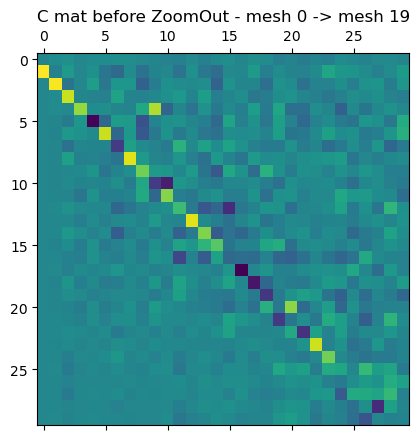

(43158, 3)
(39739, 3)
(39739,)


In [5]:
ind_1 = 0
ind_2 = 19

o_map = maps_dict[(ind_1,ind_2)]
print(f"original map shape: {o_map.shape}")

plt.matshow(o_map)
plt.title(f"C mat before ZoomOut - mesh {ind_1} -> mesh {ind_2}")
plt.show()

# Test Display
mesh_1 = mesh_list_o3d[ind_1]; mesh_2 = mesh_list_o3d[ind_2]
verts_1 = np.asarray(mesh_1.vertices)
verts_2 = np.asarray(mesh_2.vertices)

p2p_map = initial_p2p_map(verts_2,verts_1)
cmap_1 = visu(verts_1)
cmap_2 = cmap_1[p2p_map]

print(verts_1.shape)
print(verts_2.shape)
print(p2p_map.shape)

double_plot_o3d(mesh_1, mesh_2, cmap_1,cmap_2)

## Consistent Zoomout _______________________________________________
1. Create Functional Map Network (FMN)
2. Run ConsistentZoomout refinement
3. Visualise Results by converting refined maps back to point to point maps

In [12]:
from pyFM.FMN import FMN

# Build the network
fmn_model = FMN(mesh_list, maps_dict.copy())
fmn_model.compute_CCLB(m=20)

Setting 380 edges on 20 nodes.
Computing cycle information
Optimizing Cycle Weights...
	Done in 0.09561s
Computing 30 CLB eigenvectors...
	Done in 0.0s


In [13]:
# Run Consistent Zoomout
fmn_model.zoomout_refine(nit=25, step=2, subsample=3000, isometric=True, weight_type='icsm',
                    M_init=None, cclb_ratio=.9, n_jobs=1, equals_id=False,
                    verbose=True)

Computing a 3000-sized subsample for each mesh


  0%|          | 0/24 [00:00<?, ?it/s]

In [14]:
# To Save or Load Model
import pickle as p

#save
with open("../../fmn_model_MESHES_NEW_20.pkl", "wb") as f:
    p.dump(fmn_model, f)

# load
# with open("../../fmn_model_MESHES_NEW.pkl", "rb") as f:
#     fmn_model = p.load(f)

# DO NOT USE THE ONE BELOW!!!!!!!!!!!!!!!!!!!!!!!!!!!

In [64]:
K = 30
maps_dict = {}

def subsample_mesh(verts, n_samples=3000):
    if len(verts) <= n_samples:
        return verts, np.arange(len(verts))
    idx = np.random.choice(len(verts), size=n_samples, replace=False)
    return verts[idx], idx

n_meshes = len(mesh_list)
for i in tqdm(range(n_meshes)):
    for j in range(n_meshes):
        if i == j:
            continue

        verts_i, verts_j = np.asarray(mesh_list[i].vertices), np.asarray(mesh_list[j].vertices)

        # Subsample
        verts_i_sub, idx_i = subsample_mesh(verts_i)
        verts_j_sub, idx_j = subsample_mesh(verts_j)

        # Compute p2p map on subsampled vertices
        p2p_sub = initial_p2p_map(verts_j_sub, verts_i_sub)

        # Lift to full mesh safely
        p2p_ji = np.full(len(verts_j), 0, dtype=int)  # <-- use 0, not -1
        p2p_ji[idx_j] = idx_i[p2p_sub]

        maps_dict[(i, j)] = spectral.mesh_p2p_to_FM(p2p_ji, mesh_list[i], mesh_list[j], dims=K)

# Build FMN
fmn_model = FMN(mesh_list, maps_dict)

# Zoomout refine
fmn_model.zoomout_refine(
    nit=25,
    step=2,
    subsample=3000,
    isometric=True,
    weight_type='icsm',
    M_init=None,
    cclb_ratio=.9,
    n_jobs=1,
    equals_id=False,
    verbose=True
)


  0%|          | 0/20 [00:00<?, ?it/s]

Setting 380 edges on 20 nodes.
Computing a 3000-sized subsample for each mesh


  0%|          | 0/24 [00:00<?, ?it/s]

# Evaulate Model Perfromance and Results _____________________ [not working]

Optimizing Cycle Weights...
	Done in 0.10317s
Computing 78 CLB eigenvectors...
	Done in 0.4s


Text(0.5, 1.0, 'Conformal CSD')

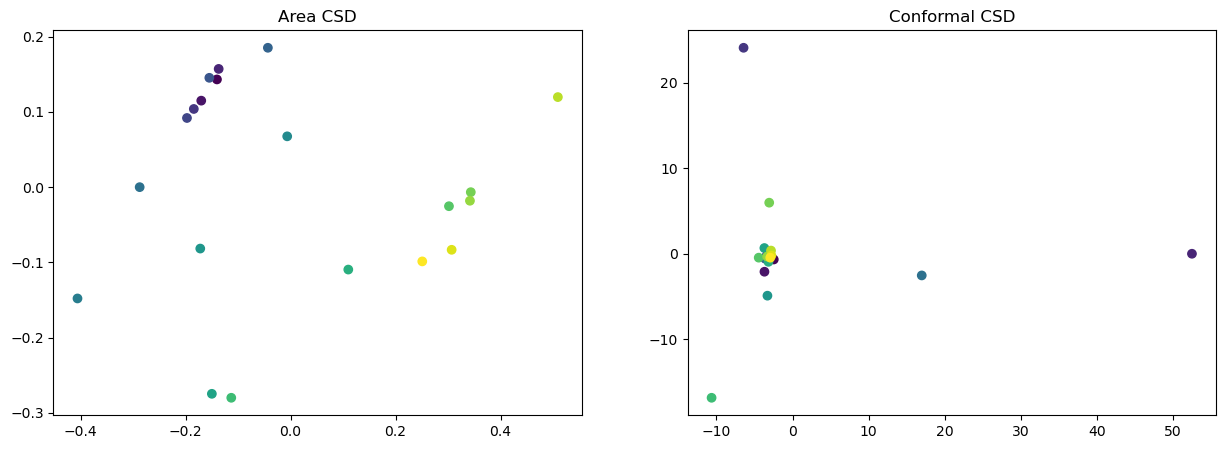

In [15]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

fmn_model.compute_CCLB(m=int(0.9*fmn_model.M))
fmn_model.cclb_eigenvalues.shape
all_embs_a = []
all_embs_c = []

for i in range(fmn_model.n_meshes):
    CSD_a, CSD_c = fmn_model.get_CSD(i)

    all_embs_a.append(CSD_a.flatten())
    all_embs_c.append(CSD_c.flatten())

all_embs_a = np.array(all_embs_a)
all_embs_c = np.array(all_embs_c)

pca_model = PCA(n_components=2)
emb_red_a = pca_model.fit_transform(all_embs_a)
emb_red_c = pca_model.fit_transform(all_embs_c)

_, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].scatter(emb_red_a[:, 0], emb_red_a[:, 1], c=np.arange(len(emb_red_a)))
axs[0].set_title('Area CSD')

axs[1].scatter(emb_red_c[:, 0], emb_red_c[:, 1], c=np.arange(len(emb_red_c)))
axs[1].set_title('Conformal CSD')

In [107]:
# Convert Back to PointWise Maps for Visualisation
fmn_model.compute_p2p()

In [109]:
new_p2p_dict = fmn_model.p2p
ind_1 = 0
ind_2 = 9

mesh1, mesh2 = mesh_list[ind_1], mesh_list[ind_2]
new_p2p_map = new_p2p_dict[(ind_1, ind_2)]

print(mesh1.vertlist.shape)
print(mesh2.vertlist.shape)
print(new_p2p_map.shape)

cmap_1 = visu(mesh1.vertlist) # pointwise is 2 -> 1? so the map is applied to ?
cmap_2 = cmap_1[new_p2p_map]
double_plot(mesh1, mesh2, cmap_1, cmap_2)

(43158, 3)
(40395, 3)
(40395,)


new map shape: (78, 78)


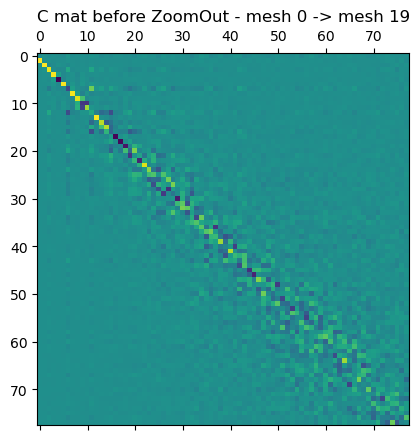

(43158, 3)
(39739, 3)
(39739,)


In [17]:
# For Display
ind_1 = 0
ind_2 = 19

mesh1, mesh2 = mesh_list[ind_1], mesh_list[ind_2]

new_maps_dict = fmn_model.maps
n_map = new_maps_dict[(ind_1, ind_2)]

print(f"new map shape: {n_map.shape}")

plt.matshow(n_map)
plt.title(f"C mat before ZoomOut - mesh {ind_1} -> mesh {ind_2}")
plt.show()

# mesh1_o3d, mesh2_o3d = mesh_list_o3d[ind_1], mesh_list_o3d[ind_2]
# verts_o3d = np.asarray(mesh1_o3d.vertices)

p2p_21 = spectral.convert.mesh_FM_to_p2p(n_map, mesh1, mesh2) # need to look at this function properly

cmap_1 = visu(mesh1.vertlist)
cmap_2 = cmap_1[p2p_21]
double_plot(mesh1, mesh2, cmap_1, cmap_2)

print(mesh1.vertlist.shape)
print(mesh2.vertlist.shape)
print(p2p_21.shape)
